In [1]:
import numpy as np
import rioxarray as rio
import matplotlib.pyplot as plt
import skimage.morphology as skimage_morphology
from matplotlib.colors import TwoSlopeNorm
from skimage.morphology import remove_small_objects, binary_closing, binary_opening, disk, dilation
from skimage.measure import label, regionprops
from scipy.ndimage import binary_dilation as scipy_dilation

In [2]:
def open_band(path):
    band_data = rio.open_rasterio(path).rio.reproject("EPSG:4326")
    band_data = band_data.where(band_data != -9999)
    band_data = (band_data * 0.0001).astype("float32")
    return band_data

In [ ]:
def hail_swath_identification(R_before, NIR_before, R_after, NIR_after, swath_threshold, min_blob_size, dilation_disk_size, prox_filter):

    ndvi_before = (NIR_before - R_before) / (NIR_before + R_before + 1e-10)
    ndvi_after  = (NIR_after  - R_after)  / (NIR_after  + R_after  + 1e-10)

    ndvi_before = ndvi_before.where((ndvi_before >= -1) & (ndvi_before <= 1))
    ndvi_after  = ndvi_after.where((ndvi_after  >= -1) & (ndvi_after  <= 1))

    diff = (ndvi_after - ndvi_before) / 2.0
    diff = diff.squeeze()

    swath_mask = diff < swath_threshold
    swath_mask = swath_mask.squeeze()
    swath_mask = skimage_morphology.opening(swath_mask, disk(2))
    swath_mask = skimage_morphology.closing(swath_mask, disk(20))
    swath_mask = remove_small_objects(swath_mask, max_size=min_blob_size)

    if prox_filter == True:
        swath_labeled = label(swath_mask)
        swath_regionprops = regionprops(swath_labeled)

        biggest_blob = max(swath_regionprops, key=lambda r: r.area)
        swath_only = (swath_labeled == biggest_blob.label)
        swath_area = scipy_dilation(swath_only, iterations=dilation_disk_size)

        final_mask = swath_only.copy()
        for blob in swath_regionprops:
            this_blob = (swath_labeled == blob.label)
            if np.any(this_blob & swath_area):
                final_mask = final_mask | this_blob

    else:
        final_mask = swath_mask
    
    swath_diff = np.where(final_mask, diff.squeeze(), np.nan)

    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    plt.figure(figsize=(6, 4))
    plt.imshow(swath_diff, cmap='RdYlGn', norm=norm)
    plt.colorbar(label='NDVI Difference')
    plt.title('Hail Swath NDVI Change')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return swath_diff

In [4]:
R_p1_before = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\IA_p_before\HLS.S30.T14TQN.2020190T170849.v2.0.B04.tif")
NIR_p1_before = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\IA_p_before\HLS.S30.T14TQN.2020190T170849.v2.0.B8A.tif")

R_p1_after = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\IA_p_after\HLS.S30.T14TQN.2021184T170849.v2.0.B04.tif")
NIR_p1_after = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\IA_p_after\HLS.S30.T14TQN.2021184T170849.v2.0.B8A.tif")

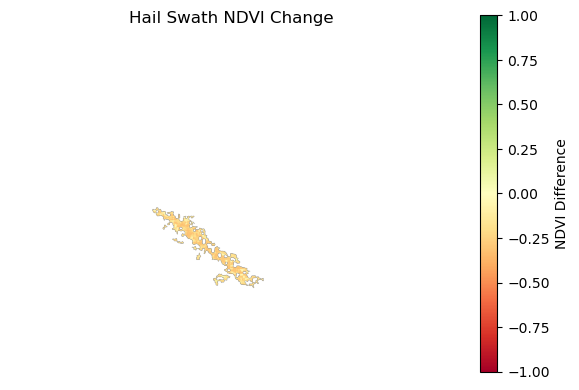

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(3215, 4368), dtype=float32)

In [15]:
hail_swath_identification(R_p1_before, NIR_p1_before, R_p1_after, NIR_p1_after, -0.18, 500, 50, True)

In [16]:
R_sp1_before = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\MT_p_before\HLS.S30.T12UVU.2024165T181921.v2.0.B04.tif")
NIR_sp1_before = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\MT_p_before\HLS.S30.T12UVU.2024165T181921.v2.0.B8A.tif")

R_sp1_after = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\MT_p_after\HLS.S30.T12UVU.2024195T181921.v2.0.B04.tif")
NIR_sp1_after = open_band(r"C:\Users\thewe\OneDrive\Desktop\final_tifs\pristine\MT_p_after\HLS.S30.T12UVU.2024195T181921.v2.0.B8A.tif")

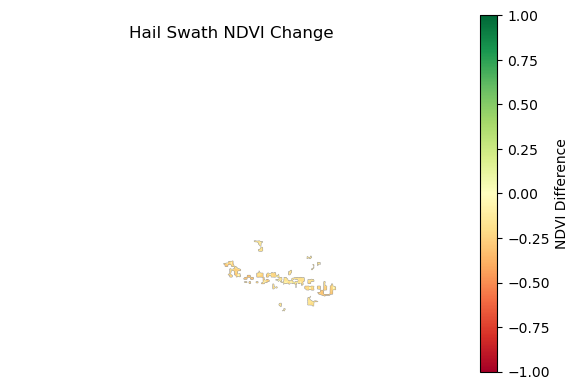

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(2888, 4333), dtype=float32)

In [ ]:
hail_swath_identification(R_sp1_before, NIR_sp1_before, R_sp1_after, NIR_sp1_after, -0.15, 200, 300, True)